STEP 1: Project Overview

# Stock Price Prediction Using Time Series Analysis
using Python, Pandas, NumPy, Scikit-Learn, Statsmodels, TensorFlow/Keras, Matplotlib

### Project Objective:
To build, evaluate, and compare statistical, machine learning, and deep learning models (Linear Regression, Random Forest, ARIMA, and LSTM) to forecast future stock prices.

STEP 2: Dependencies & Data Loading

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# For fetching data (Using yfinance for actual data retrieval)
# Run !pip install yfinance if you don't have it installed
import yfinance as yf

# Set plot style
plt.style.use('fivethirtyeight')
%matplotlib inline

# Load historical data (Example: Apple Inc. for a 5-year period)
ticker = 'AAPL'
start_date = '2019-01-01'
end_date = '2024-01-01'

df = yf.download(ticker, start=start_date, end=end_date)
print(f"Dataset loaded with {df.shape[0]} rows.")
df.head()

[*********************100%***********************]  1 of 1 completed

Dataset loaded with 1258 rows.


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.469200,37.689860,36.593684,36.750281,148158800
2019-01-03,33.736984,34.574536,33.691903,34.161690,365248800
2019-01-04,35.177208,35.246017,34.118999,34.292203,234428400
2019-01-07,35.098892,35.312435,34.617241,35.281589,219111200
2019-01-08,35.768005,36.021883,35.238901,35.485657,164101200


STEP 3: Data Preprocessing & EDA

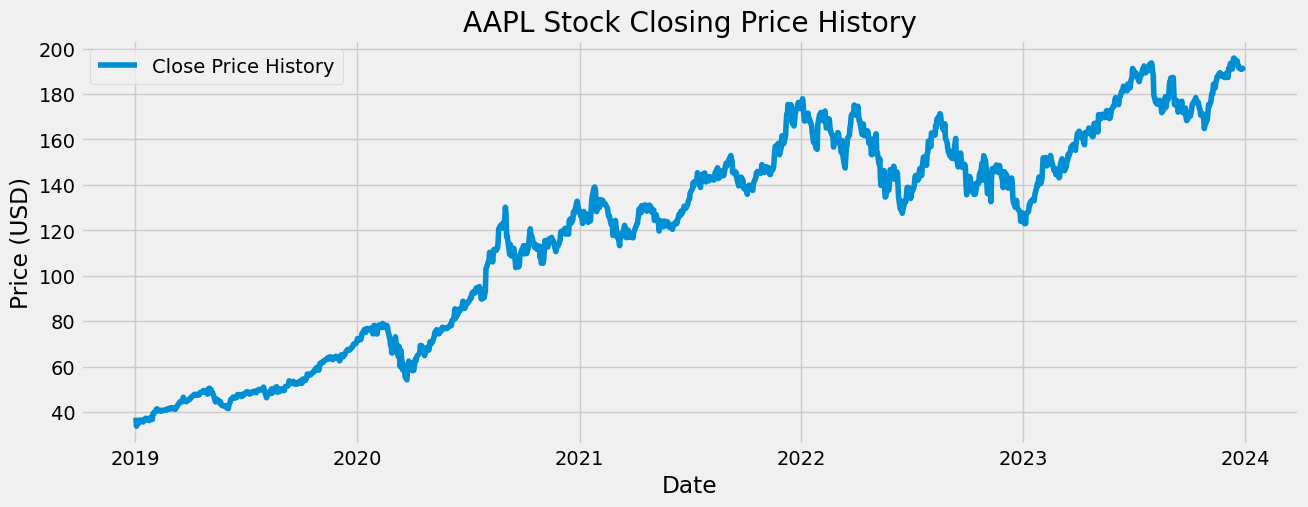

Price,Close,Log_Return,MA_7,MA_21,Lag_1
Ticker,AAPL,,,,
Date,,,,,
2019-01-31,39.490723,0.007175,37.523778,36.578548,39.208374
2019-02-01,39.509705,0.000481,37.950859,36.675715,39.490723
2019-02-04,40.631969,0.028009,38.579616,37.004048,39.509705
2019-02-05,41.327168,0.016965,39.136176,37.296903,40.631969
2019-02-06,41.341404,0.000344,39.744258,37.594166,41.327168


In [2]:
# Keep only the Close price for univariate analysis
data = df[['Close']].copy()

# Visualize historical closing price
plt.figure(figsize=(14, 5))
plt.plot(data['Close'], label='Close Price History')
plt.title(f'{ticker} Stock Closing Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Technical Indicators Feature Engineering (for ML Models)
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['MA_7'] = data['Close'].rolling(window=7).mean()
data['MA_21'] = data['Close'].rolling(window=21).mean()
data['Lag_1'] = data['Close'].shift(1)

# Drop missing values caused by lagging/rolling windows
data.dropna(inplace=True)
data.head()

STEP 4: Stationarity Check for ARIMA

### Stationarity Check
Traditional time series models like ARIMA require the data to be stationary. We use the **Augmented Dickey-Fuller (ADF) Test** to verify this.

STEP 5: ADF Test

In [3]:
from statsmodels.tsa.stattools import adfuller

# Run ADF Test on Raw Close Price
result = adfuller(data['Close'])
print('ADF Statistic (Raw Close):', result[0])
print('p-value:', result[1])

# Run ADF Test on Differenced Data (Log Returns)
result_diff = adfuller(data['Log_Return'])
print('\nADF Statistic (Log Returns):', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic (Raw Close): -1.1778900496901714
p-value: 0.6830338160119137

ADF Statistic (Log Returns): -10.978006385185271
p-value: 7.583082892745036e-20


STEP 6: Model 1 & 2: Linear Regression & Random Forest

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features and Target
X = data[['MA_7', 'MA_21', 'Lag_1']].values
y = data['Close'].values

# Time-series split (Train: 80%, Test: 20%)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Baseline ML models successfully trained.")

C:\Users\acer\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline ML models successfully trained.


STEP 7: Model 3: ARIMA

In [7]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA relies entirely on the historical sequential target values
train_series = y_train

# Fitting an ARIMA(1, 1, 1) model as a baseline
arima_model = ARIMA(train_series, order=(1, 1, 1))
arima_fitted = arima_model.fit()

# Forecast for the length of the test set
arima_preds = arima_fitted.forecast(steps=len(y_test))
print("ARIMA model successfully trained and forecasted.")

ARIMA model successfully trained and forecasted.


STEP 8: Model 4: Deep Learning - LSTM

In [8]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data['Close'].values.reshape(-1,1))

# Create training sequences (60-day window)
prediction_days = 60
x_lstm, y_lstm = [], []

for x in range(prediction_days, len(scaled_data)):
    x_lstm.append(scaled_data[x-prediction_days:x, 0])
    y_lstm.append(scaled_data[x, 0])
    
x_lstm, y_lstm = np.array(x_lstm), np.array(y_lstm)
x_lstm = np.reshape(x_lstm, (x_lstm.shape[0], x_lstm.shape[1], 1))

# LSTM Split
lstm_split = int(len(x_lstm) * 0.8)
X_train_lstm, X_test_lstm = x_lstm[:lstm_split], x_lstm[lstm_split:]
y_train_lstm, y_test_lstm = y_lstm[:lstm_split], y_lstm[lstm_split:]

# Build LSTM Architecture
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=1)

# Predict and Inverse Transform
lstm_preds_scaled = model.predict(X_test_lstm)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)

# Align actual target values for matching LSTM test dimensions
y_test_lstm_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0645
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0071
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0051
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0045
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0041
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0037
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0039
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0036
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0032
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0035
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


STEP 9: Comparative Evaluation Dashboard

--- Linear Regression Performance ---
RMSE: 2.14
MAE:  1.66
R2:   0.98

--- Random Forest Performance ---
RMSE: 8.97
MAE:  6.31
R2:   0.72

--- LSTM Performance ---
RMSE: 5.82
MAE:  5.02
R2:   0.84



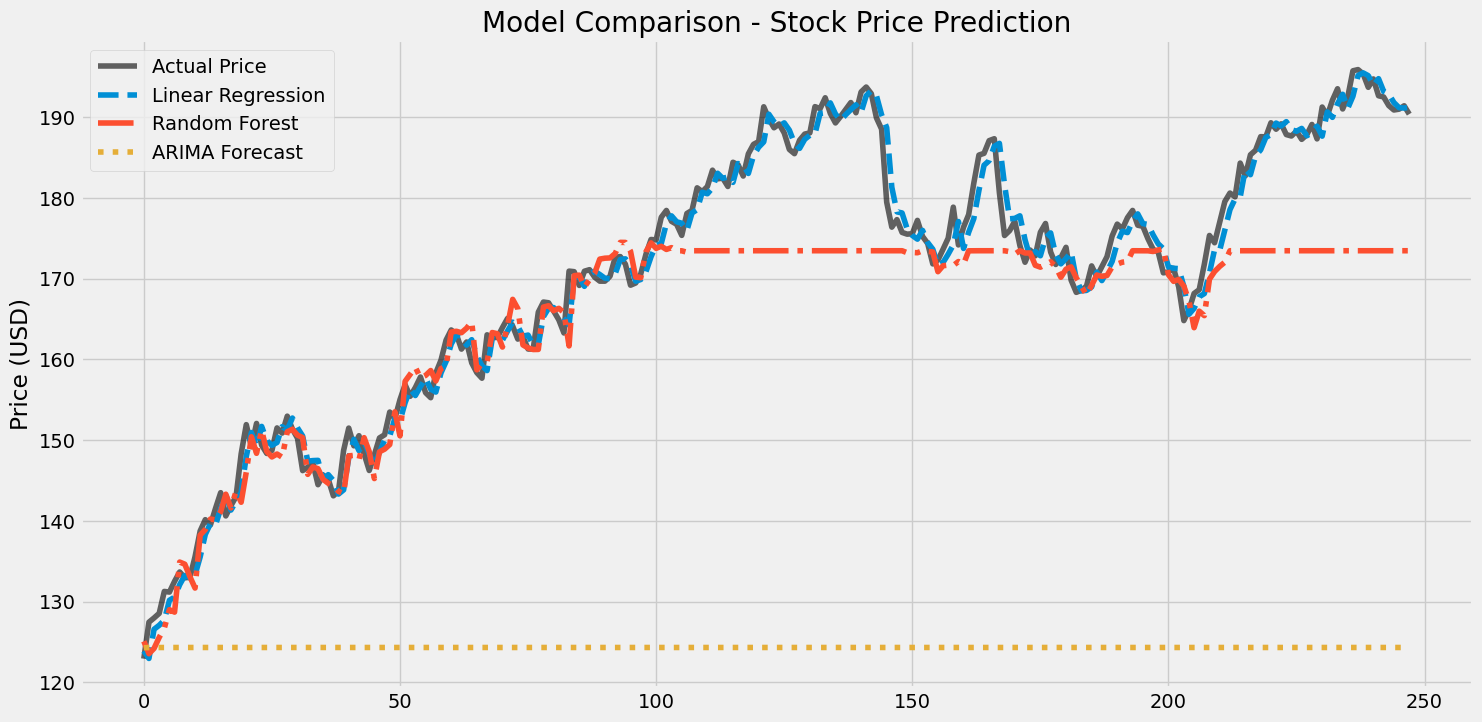

In [9]:
# To align evaluations cleanly, let's look at the standard ML/Statistical test window 
# (Note: For your final portfolio, you can align exact dates across all models)

def calculate_metrics(actual, pred, name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.2f}\n")
    return [rmse, mae, r2]

lr_metrics = calculate_metrics(y_test, lr_preds, "Linear Regression")
rf_metrics = calculate_metrics(y_test, rf_preds, "Random Forest")
lstm_metrics = calculate_metrics(y_test_lstm_actual, lstm_preds, "LSTM")

# Visualizing the Predictions
plt.figure(figsize=(16, 8))
plt.plot(y_test, label='Actual Price', color='black', alpha=0.6)
plt.plot(lr_preds, label='Linear Regression', linestyle='--')
plt.plot(rf_preds, label='Random Forest', linestyle='-.')
plt.plot(arima_preds, label='ARIMA Forecast', linestyle=':')
plt.title('Model Comparison - Stock Price Prediction')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()